(628.7883507554781, 0.46491409089201524)
(259.80772204980303, 0.5615238075263915)
(201.7882856858298, 0.48567294206220224)
(169.1299974242429, 0.4618405906969399)
(123.0134950183357, 0.4309078483871919)
(104.74429542713891, 0.38745533073845795)
(91.68332329896344, 0.4243597896464073)
(83.52526208040277, 0.4242050638091782)
(75.74441266703246, 0.41499786164295727)
(65.88006303758368, 0.4026668544135128)
(64.17899519691714, 0.3728664229534219)


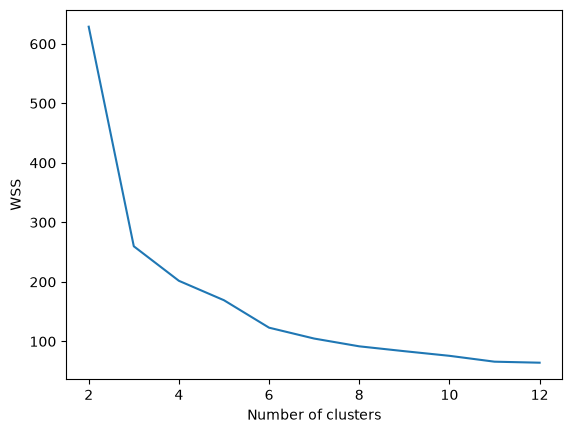

(259.80772204980303, 0.5615238075263915, [np.float64(0.44951299286014973), np.float64(0.6191660970520857), np.float64(0.6452086184700055)])


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

wine = load_wine()
#standardization
scaler = StandardScaler()
wine.data= scaler.fit_transform(wine.data)

#PCA

def do_pca(data, components:int = 2, is_plot:bool = False, target = None, exp_variance:bool = False):
    pca_model = PCA(n_components=components, random_state= 100)
    pca_data= pca_model.fit(data)
    reduced_data= pca_data.transform(data)
    if is_plot:
        sns.scatterplot(x = reduced_data[:,0], y = reduced_data[:,1], hue = target, palette="icefire")
        plt.show()

    if exp_variance:
        return pca_data.explained_variance_ratio_
    return reduced_data

def explained_variance_sum(list_var, is_verbose:bool = False, is_plot:bool = False) -> list[float]:
    cumulative_sums = []
    sum = 0
    for i in range(len(list_var)):
        sum += list_var[i]
        cumulative_sums.append(sum)
        if is_verbose:
            print(f"Variance until explained up to and including {i}th component: {sum}")

    if is_plot:
        sns.lineplot(x = [i for i in range(13)], y = cumulative_sums)
        plt.show()
    return cumulative_sums

def do_kmeans(data, n_clusters:int = 8, is_plot:bool = False, is_cluster_silhouette:bool = False):
    kmeans = KMeans(n_clusters=n_clusters, random_state= 100).fit(data)
    wss = kmeans.inertia_
    clustered_data = kmeans.predict(data)
    if is_plot:
        if len(data[0]) != 2:
            raise Exception("Number of components has to be 2 to make a plot")
        sns.scatterplot(x = data[:,0], y = data[:,1], hue = clustered_data, palette="icefire")
        plt.show()
    if is_cluster_silhouette:
        sample_silhouette_values = silhouette_samples(data, clustered_data)
        cluster_silhouette_values = []
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[clustered_data == i]
            cluster_silhouette_values.append(np.mean(ith_cluster_silhouette_values))
        return wss, silhouette_score(data, clustered_data), cluster_silhouette_values
    return wss, silhouette_score(data, clustered_data)


#do_kmeans(do_pca(wine.data, 2), 3, is_plot= True)

def compare_kmeans(min_n_clusters,max_n_clusters, is_elbow_plot:bool = False, is_verbose:bool = False):
    wss_scores = []
    sihlouette_scores = []
    for i in range(min_n_clusters, max_n_clusters + 1):
        curr_score = do_kmeans(do_pca(wine.data, 2), n_clusters= i)
        wss_scores.append(curr_score[0])
        sihlouette_scores.append(curr_score[1])
        if is_verbose:
            print(curr_score)
    if is_elbow_plot:
        sns.lineplot(x = [i for i in range(min_n_clusters, max_n_clusters + 1)], y = wss_scores)
        plt.xlabel("Number of clusters")
        plt.ylabel("WSS")
        plt.show()

    return wss_scores, sihlouette_scores

compare_kmeans(2, 12, is_elbow_plot= True, is_verbose= True)

print(do_kmeans(do_pca(wine.data, components= 2), n_clusters= 3, is_cluster_silhouette= True))


# Part 2: Clustering

## 1. Apply K-Means

1. Since K-Means is an unsupervised learning algorithm it operates without beaing able to look at the actual wine labels.

2. Classes are the true classifications of the samples, which is typically used in supervised learning. Clusters are similar data points that are grouped together by the machine learning algorithm, typically unsupervised, where we do not have access to actual classes.

## 2. Visualize the clusters using PCA

1. In our plot we can see three clusters.
2. No, the clusters look quite spread.
3. Yes, the clusters are very similar to the actual plot of the wine classes.


## 3. Experiment with a different number of clusters

1. The WSS decreases when k increases, but silhouette score does not increase, peaks at 3 clusters (same as amount of true classes).
2. k = 3 gives the strongest agreement with the known classes beacuse
3. We usually do not know the actual classes, so we should not rely on it. Also, clustering is about discovering patterns in the data. There might be important patterns which are different from the true classes, that we might miss if we hyperfixate on it.


## 4. The Elbow Method

In [ ]:
def compare_kmeans(min_n_clusters,max_n_clusters, is_elbow_plot:bool = False, is_verbose:bool = False):
    wss_scores = []
    sihlouette_scores = []
    for i in range(min_n_clusters, max_n_clusters + 1):
        curr_score = do_kmeans(do_pca(wine.data, 2), n_clusters= i)
        wss_scores.append(curr_score[0])
        sihlouette_scores.append(curr_score[1])
        if is_verbose:
            print(curr_score)
    if is_elbow_plot:
        sns.lineplot(x = [i for i in range(min_n_clusters, max_n_clusters + 1)], y = wss_scores)
        plt.xlabel("Number of clusters")
        plt.ylabel("WSS")
        plt.show()

    return wss_scores, sihlouette_scores

compare_kmeans(2, 12, is_elbow_plot= True, is_verbose= True)

print(do_kmeans(do_pca(wine.data, components= 2), n_clusters= 3, is_cluster_silhouette= True))


We think that the elbow occurs at 3, since that is the number of classes. After printing it, we weren't sure at which K it occurred, thus, we decided to look at the silhouette score. With that, we got that the average of the 3 clusters was the best among the other possible k values since it only had one cluster below 0.5, meaning that we were right. 

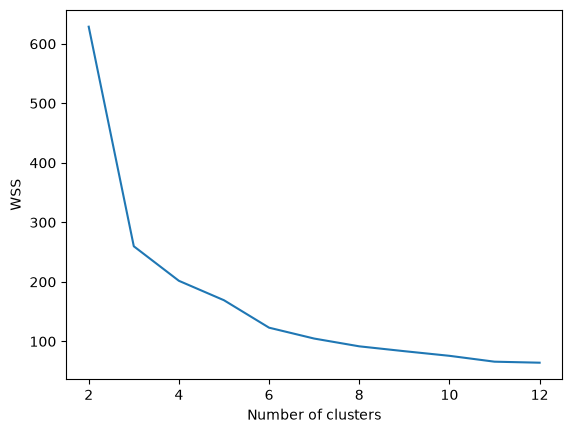
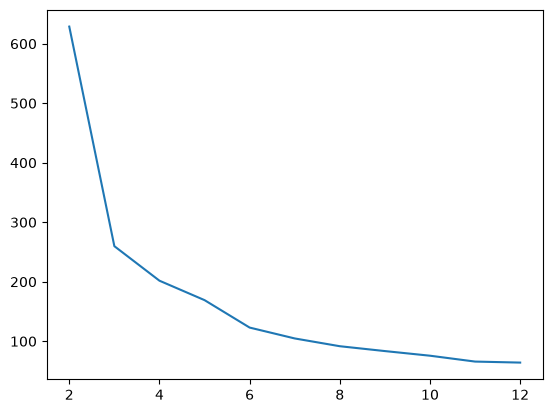